<!-- mtlearn-icpr2026-doc -->
# ICPR 2026 - Screw Segmentation - U-Net MobileNetV2 - run_000

Paper: **A trainable connected filter preprocessing layer based on component trees**.

This notebook reproduces the representative `run_000` execution for the `Screw Segmentation / U-Net MobileNetV2` configuration. It compares the baseline backbone against the same backbone preceded by Connected Filter Preprocessing (CFP).

| Field | Value |
| --- | --- |
| Dataset | Screw Segmentation |
| Dataset key | `screws_segmentation` |
| Task | Foreground/background screw segmentation |
| Backbone | U-Net MobileNetV2 |
| Variants | Baseline, CFP |
| Run | `run_000` |
| Seed | `2684470948` |
| Paper role | Representative run for the corresponding paper configuration |

The paper aggregates were computed from 10 independent seeds per configuration. This notebook keeps one executed run as a readable and rerunnable artifact for RRPR review.


<!-- mtlearn-icpr2026-doc -->
## Run Parameters

The first cells define the run identifier, random seed, and output directory used by the executed experiment. They are kept as code cells so the notebook remains compatible with Papermill-style batch execution.


<!-- mtlearn-icpr2026-doc -->
## Paper Output Map

- Table 2 (SWP / screw segmentation metrics): the single-run metric rows are extracted from `results_df_base` in **Baseline Evaluation** and `results_df` in **CFP Evaluation**. The paper table reports mean and standard deviation over 10 runs, so this notebook provides the representative `run_000` execution.
- Figure 3: Figure 3 is not extracted from this notebook; the paper figure uses ConvNet and ED3-NN qualitative examples.
- Table 3: Table 3 is not extracted from this notebook; the paper reports attribute ablation only for ED3-NN.


In [1]:
# Parameters
RUN_ID = 0
SEED = 2684470948
OUTPUT_DIR = None
DATASET_SCALE_IN = False


<!-- mtlearn-icpr2026-doc -->
## Environment and Helpers

This setup imports PyTorch, MTLearn morphology utilities, plotting utilities, and the shared RRPR notebook helpers from `icpr2026_utils.py`. The selected device follows this priority: CUDA, Apple MPS, then CPU.


In [3]:
from pathlib import Path
import sys

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import numpy as np
from mtlearn import morphology
import mtlearn
import matplotlib.pyplot as plt

for helper_dir in (Path.cwd(), Path.cwd() / "notebooks" / "ICPR2026"):
    if (helper_dir / "icpr2026_utils.py").exists():
        sys.path.insert(0, str(helper_dir.resolve()))
        break
else:
    raise FileNotFoundError("Could not locate notebooks/ICPR2026/icpr2026_utils.py")

from icpr2026_utils import (
    default_device,
    evaluate_train_test,
    fix_randomness,
    rank_cfp_attributes,
    save_evaluation_tables,
    show_figure3_panels,
    train_with_notebook_context,
)

np.set_printoptions(precision=3, suppress=True)
fix_randomness(SEED)
generator = torch.Generator(device="cpu")
generator.manual_seed(SEED)

device = default_device()
print("Device:", device)


/Users/wonderalexandre/GitHub/MTLearn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


# Dataset


<!-- mtlearn-icpr2026-doc -->
The screw dataset is loaded through `mtlearn.data.ensure_dataset("screws_segmentation")`, which downloads or locates the public data used by this experiment. The dataset section resizes the input images, builds the train/test split, and prepares tensors for binary segmentation. The next cell also estimates foreground/background imbalance so the loss can compensate for sparse positive pixels.


In [4]:
num_cols, num_rows =(int(1177 * 0.5), int(1324 * 0.499))
print("Resolution: ", num_cols, "x", num_rows)

dir_name = str(mtlearn.data.ensure_dataset("screws_segmentation"))
dataset = mtlearn.datasets.PairedImageDataset(root_dir=dir_name, grayscale_in=True, invert_in=True, invert_target=True,  num_rows=num_rows, num_cols=num_cols, scale_in=DATASET_SCALE_IN, suffix_in="_in", suffix_target="_target")
trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
print("Train set:", len(trainset))
print("Test set:", len(testset))

# Move train/test sets to the selected device
trainset = [(inputs.to(device), targets.to(device), file_names) for inputs, targets, file_names in trainset]
testset= [(inputs.to(device), targets.to(device), file_names) for inputs, targets, file_names in testset]
trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True, pin_memory=False, generator=generator)


Resolution:  588 x 660
screws_segmentation: already available at /Users/wonderalexandre/GitHub/MTLearn/dat/screws_segmentation
Train set: 34
Test set: 15


In [5]:
# Compute the class-imbalance ratio
num_neg = []
num_pos = []
for i in range(len(trainset)):
    x, y, _ = trainset[i]
    num_neg.append((y == 0).sum().item())
    num_pos.append((y == 1).sum().item())

# Compute class proportions
total_neg = sum(num_neg)
total_pos = sum(num_pos)
total_samples = total_neg + total_pos

percent_neg = (total_neg / total_samples) * 100
percent_pos = (total_pos / total_samples) * 100

print(f"Total class 0 samples: {total_neg} ({percent_neg:.2f}%)")
print(f"Total class 1 samples: {total_pos} ({percent_pos:.2f}%)")

pos_weight = torch.tensor([total_neg / total_pos])  # 8498057 / 530683 ~= 16
print(f"pos_weight: {pos_weight}")


Total class 0 samples: 12935189 (98.03%)
Total class 1 samples: 259531 (1.97%)
pos_weight: tensor([49.8406])


# Models


<!-- mtlearn-icpr2026-doc -->
The model section defines two comparable variants. `BaseNet` is the U-Net MobileNetV2 backbone used as the neural baseline. `BackboneWithConnectedFilterLayer` wraps the same backbone with a CFP layer so the network receives a learnable connected-filtered representation before segmentation.


In [6]:
class BaseNet(nn.Module):
    """U-Net MobileNetV2 segmentation backbone used as the baseline network."""
    def __init__(self, num_rows, num_cols, device='cpu'):
        """Create the backbone layers and move the module to the selected device."""
        super(BaseNet, self).__init__()
        self.device = device
        self.num_rows = num_rows
        self.num_cols = num_cols

        # Fully connected layer and LayerNorm running on the GPU
        self.net = smp.Unet(
            encoder_name="mobilenet_v2",
            encoder_weights=None,
            in_channels=1,
            encoder_depth=3,
            decoder_channels=(32, 16, 8),
            classes=1
        ).to(device)

    def forward(self, inputs):
        """Run the backbone forward pass and return segmentation logits."""
        if type(inputs) == list:
            out = self.net(inputs[0])
        else:
            out = self.net(inputs)
        return out


class BackboneWithConnectedFilterLayer(nn.Module):
    """Compose the CFP layer with the backbone for CFP-enhanced segmentation."""
    def __init__(self, layer_connected_filter, num_rows, num_cols, device='cpu'):
        """Store the CFP layer, create the downstream backbone, and keep both on the selected device."""
        super(BackboneWithConnectedFilterLayer, self).__init__()
        self.device = device
        self.morphological_layer = layer_connected_filter
        self.net = BaseNet(num_rows, num_cols, device)


    def forward(self, inputs):
        """Apply CFP to the input image and feed the filtered tensor into the backbone."""
        self.h_filter = self.morphological_layer(inputs)
        return self.net(self.h_filter)


<!-- mtlearn-icpr2026-doc -->
## CFP Layer Configuration

The CFP layer is configured with a max-tree and a set of morphological attributes. During training, the layer learns how to combine connected filters before passing the transformed image to the backbone, allowing the comparison to isolate the effect of morphological preprocessing.


In [7]:
Type = morphology.AttributeType
tree_type = morphology.TreeType.MAX_TREE
layer_connected_filter = mtlearn.layers.ConnectedFilterPreprocessingLayer(
    in_channels=1,
    filter_specs=[
        {
            "tree_type": tree_type,
            "attributes": (
                Type.CIRCULARITY,
                Type.INERTIA,
                Type.AREA,
                Type.LENGTH_MINOR_AXIS,
                Type.GRAY_HEIGHT,
                Type.LENGTH_MAJOR_AXIS,
                Type.RECTANGULARITY,
            ),
        },
    ],
    device=device,
    clamp=None,
)

# Create a cached train loader used during training
trainloader_cached = layer_connected_filter.build_dataloader_cached(trainloader)
layer_connected_filter.init_identity()


()

# Training


<!-- mtlearn-icpr2026-doc -->
The training wrapper below delegates the repeated optimizer, class-balanced BCE loss, CFP auxiliary loss, and loss-curve plotting logic to `icpr2026_utils.py`. The visible calls still keep the paper parameters explicit for baseline and CFP-enhanced runs.


In [8]:
def training(model, lr=0.001, lr_cfp=0.05, lambda_filter=1, num_epochs_filter=0, num_epochs=100):
    return train_with_notebook_context(
        model,
        trainloader=trainloader,
        trainloader_cached=trainloader_cached,
        pos_weight=pos_weight,
        device=device,
        lr=lr,
        lr_cfp=lr_cfp,
        lambda_filter=lambda_filter,
        num_epochs_filter=num_epochs_filter,
        num_epochs=num_epochs,
    )


<!-- mtlearn-icpr2026-doc -->
## Baseline Training

This run trains the U-Net MobileNetV2 backbone without CFP. It provides the reference performance for the dataset, architecture, seed, and training schedule used in this notebook.


Epoch 0, Loss: 1.0783979, Learning rate: 0.001000


Epoch 10, Loss: 0.5543188, Learning rate: 0.001000


Epoch 20, Loss: 0.3211779, Learning rate: 0.001000


Epoch 30, Loss: 0.1275437, Learning rate: 0.001000


Epoch 40, Loss: 0.0566489, Learning rate: 0.001000


...

Epoch 60, Loss: 0.0245846, Learning rate: 0.001000


Epoch 70, Loss: 0.0188566, Learning rate: 0.001000


Epoch 80, Loss: 0.0158378, Learning rate: 0.001000


Epoch 90, Loss: 0.0129377, Learning rate: 0.001000


Epoch 99, Loss: 0.0112209, Learning rate: 0.001000
Finish training
Execution time: 2.132 minutes


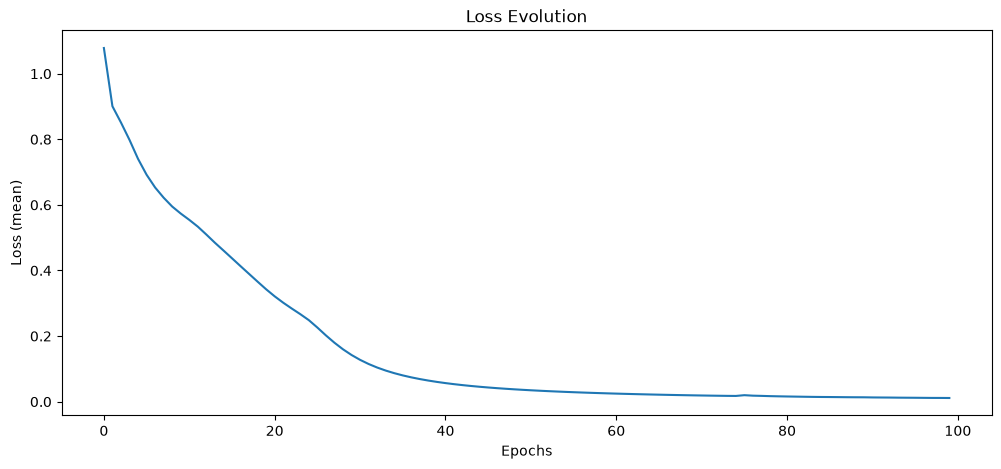

[1.0783978700637817,
 0.9007176041603089,
 0.8511397361755371,
 0.7981764554977417,
 0.7403140187263488,
 0.691963529586792,
 0.6530296444892884,
 0.6218762040138245,
 0.5949496865272522,
 0.5735920786857605,
 0.5543188095092774,
 0.5336400151252747,
 0.5095087349414825,
 0.484593665599823,
 0.46103026270866393,
 0.4372248947620392,
 0.41327223777770994,
 0.38960148096084596,
 0.36591201424598696,
 0.3426558017730713,
 0.3211778819561005,
 0.30176390409469606,
 0.2839790105819702,
 0.2668387949466705,
 0.24854372143745423,
 0.2259861022233963,
 0.20204101800918578,
 0.17967958450317384,
 0.15966332852840423,
 0.14235760569572448,
 0.12754365503787995,
 0.11488274484872818,
 0.10410280078649521,
 0.09487514346837997,
 0.0869592621922493,
 0.08010176718235015,
 0.0741477519273758,
 0.06893267035484314,
 0.06433912888169288,
 0.06027164310216904,
 0.056648940593004224,
 0.053402279317378995,
 0.05048361718654633,
 0.04784637317061424,
 0.0454543374478817,
 0.04327434152364731,
 0.04127676

In [9]:
model_base = BaseNet(num_rows, num_cols, device)
training(model_base, lr=0.001, num_epochs=100)


<!-- mtlearn-icpr2026-doc -->
## Backbone with CFP Training

This run trains the same backbone with CFP placed before it. The goal is to measure whether the learnable connected operator improves segmentation when all other experimental conditions remain aligned with the baseline.


Epoch 0, Loss: 175403449.6000000, Learning rate: 0.001000
	Loss (main): 0.9836254, Loss (filter): 51898080.0000000, Lambda: 1.0000


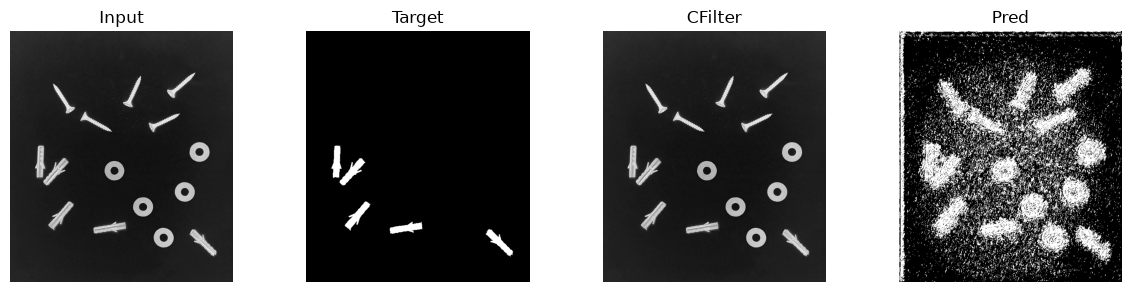

Epoch 10, Loss: 1869134.9750000, Learning rate: 0.001000
	Loss (main): 0.4125725, Loss (filter): 696779.0000000, Lambda: 0.8000


Epoch 20, Loss: 1284798.8187500, Learning rate: 0.001000
	Loss (main): 0.0920128, Loss (filter): 631906.8750000, Lambda: 0.6000


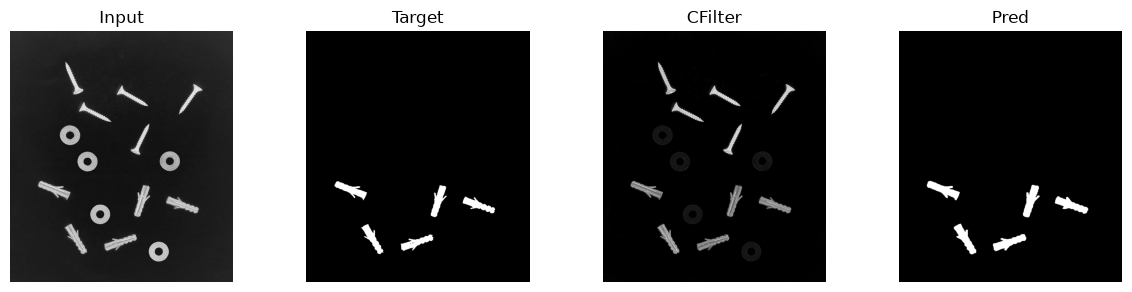

Epoch 30, Loss: 816217.1250000, Learning rate: 0.001000
	Loss (main): 0.0306241, Loss (filter): 599154.7500000, Lambda: 0.4000


Epoch 40, Loss: 397318.1343750, Learning rate: 0.001000
	Loss (main): 0.0162469, Loss (filter): 580576.8750000, Lambda: 0.2000


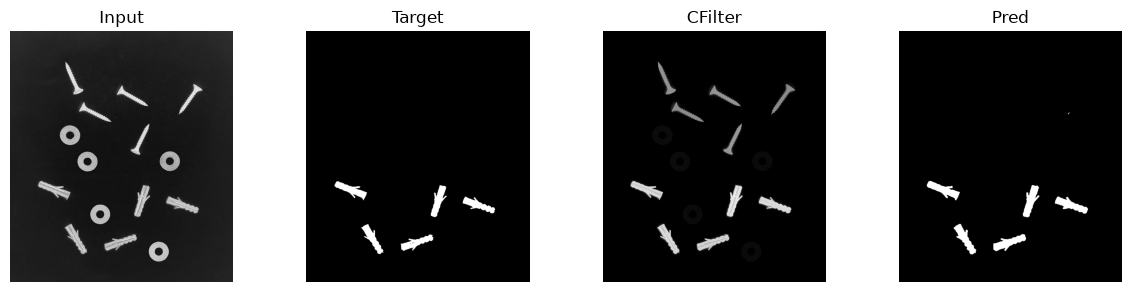

Epoch 50, Loss: 0.0281793, Learning rate: 0.001000


Epoch 60, Loss: 0.0095222, Learning rate: 0.001000


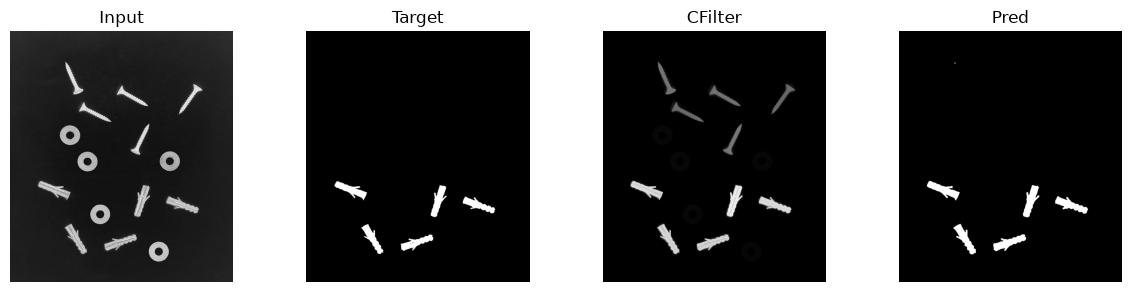

Epoch 70, Loss: 0.0077940, Learning rate: 0.001000


Epoch 80, Loss: 0.0070997, Learning rate: 0.001000


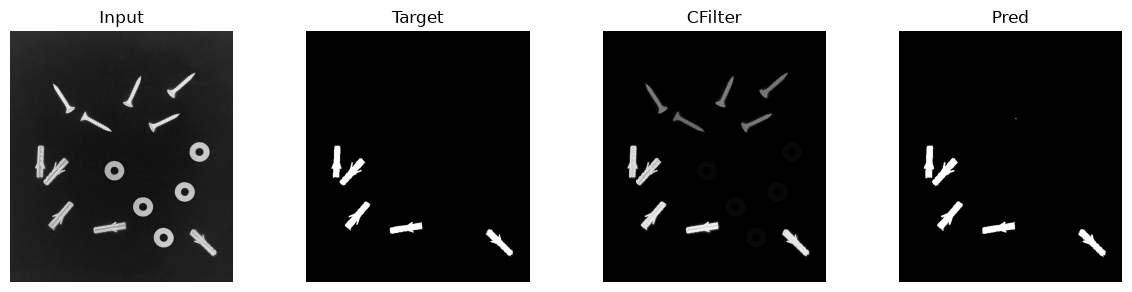

Epoch 90, Loss: 0.0064776, Learning rate: 0.001000


Epoch 99, Loss: 0.0060208, Learning rate: 0.001000


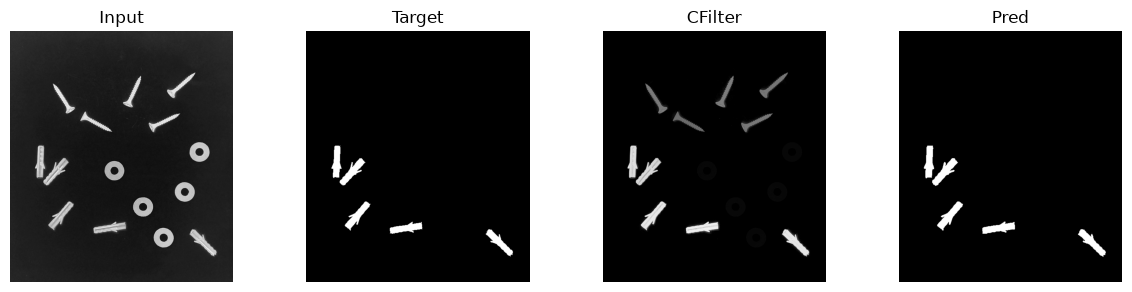

Finish training
Execution time: 3.153 minutes


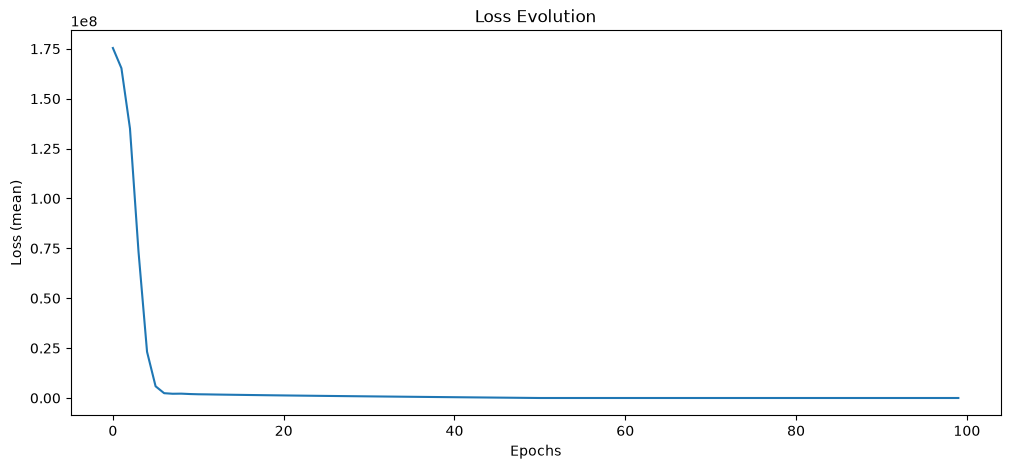

[175403449.6,
 165266288.0,
 135091793.6,
 73348479.8,
 23152325.25,
 5876365.05,
 2412132.0,
 2124645.7,
 2179561.5875,
 1988442.025,
 1869134.975,
 1814572.5125,
 1739363.6,
 1676795.1375,
 1617037.4875,
 1559936.19375,
 1501045.25,
 1445599.85,
 1390324.40625,
 1336833.65,
 1284798.81875,
 1234230.56875,
 1184584.6375,
 1136050.125,
 1088303.60625,
 1041345.4,
 995144.0625,
 949532.78125,
 904560.6125,
 860133.696875,
 816217.125,
 772807.70625,
 729757.540625,
 687256.615625,
 644866.103125,
 602990.403125,
 561146.740625,
 519784.990625,
 478596.221875,
 437713.6109375,
 397318.134375,
 356882.3015625,
 316859.103125,
 276823.075,
 236949.603125,
 197262.6421875,
 157600.87890625,
 118090.77890625,
 78635.580078125,
 39267.6744140625,
 0.028179265558719635,
 0.027600234374403954,
 0.04174043983221054,
 0.029816343635320663,
 0.017501156590878964,
 0.015191292203962804,
 0.012225635163486005,
 0.011293390765786171,
 0.010491527989506722,
 0.0099050872027874,
 0.009522182308137417,


In [10]:
model = BackboneWithConnectedFilterLayer(layer_connected_filter, num_rows, num_cols, device=device)
training(model, lr=0.001, lr_cfp=0.05, num_epochs_filter=50, num_epochs=100)


<!-- mtlearn-icpr2026-doc -->
## Threshold Selection and Metrics

The shared helpers select the `train_pr` operating threshold on the training split using the precision-recall F1 criterion, then build the Train/Test metric tables in the evaluation cells below. This notebook uses `metric_average="per_image"` for the metric aggregation mode.


<!-- mtlearn-icpr2026-doc -->
## Baseline Evaluation

**Paper extraction: Table 2, `U-Net MobileNetV2` without CFP.** The next code cell selects the `train_pr` operating threshold on the training split, evaluates the baseline on train/test splits, and exposes the `U-Net MobileNetV2` without-CFP metric rows in `results_df_base`. The test row is the value aggregated for Table 2.


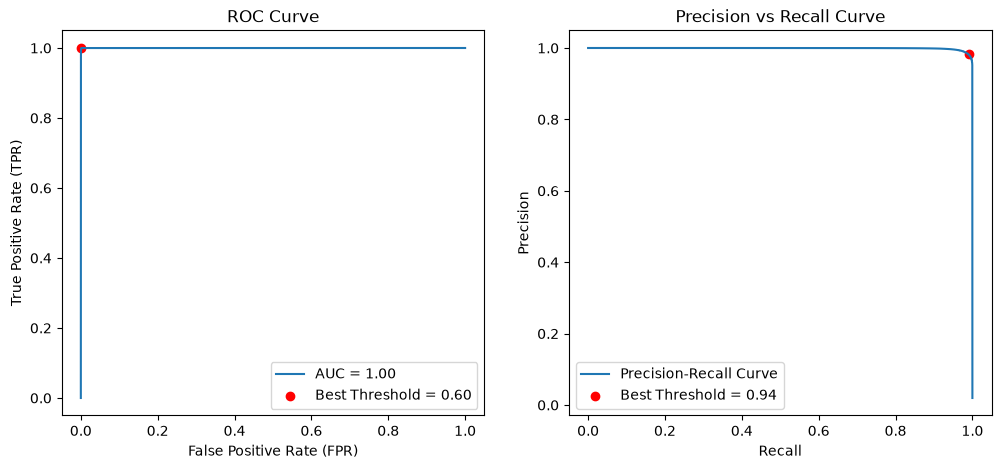

Train ROC threshold: 0.60
Train precision-recall threshold: 0.94


,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score,AUC-ROC,Jaccard Index,Cohen's Kappa,MCC,Threshold
Train,0.999445,0.981966,0.989971,0.999635,0.985949,0.999979,0.972295,0.985666,0.985676,0.938832
Test,0.999156,0.978387,0.978844,0.999565,0.978580,0.999665,0.958152,0.978149,0.978168,0.938832


In [11]:
threshold_base, results_df_base = evaluate_train_test(
    model_base,
    trainset,
    testset,
    metric_average="per_image",
)
save_evaluation_tables(
    OUTPUT_DIR,
    "base",
    results_df_base,
    metadata={
        "DATASET": "Screws",
        "MODEL": "U-Net MobileNetV2",
        "VARIANT": "Baseline",
        "RUN_ID": RUN_ID,
        "SEED": SEED,
    },
)
results_df_base


<!-- mtlearn-icpr2026-doc -->
## CFP Evaluation

**Paper extraction: Table 2, `U-Net MobileNetV2` with CFP.** The next code cell selects the `train_pr` operating threshold on the training split, evaluates the CFP model on train/test splits, and exposes the `U-Net MobileNetV2` with-CFP metric rows in `results_df`. The test row is the value aggregated for Table 2.


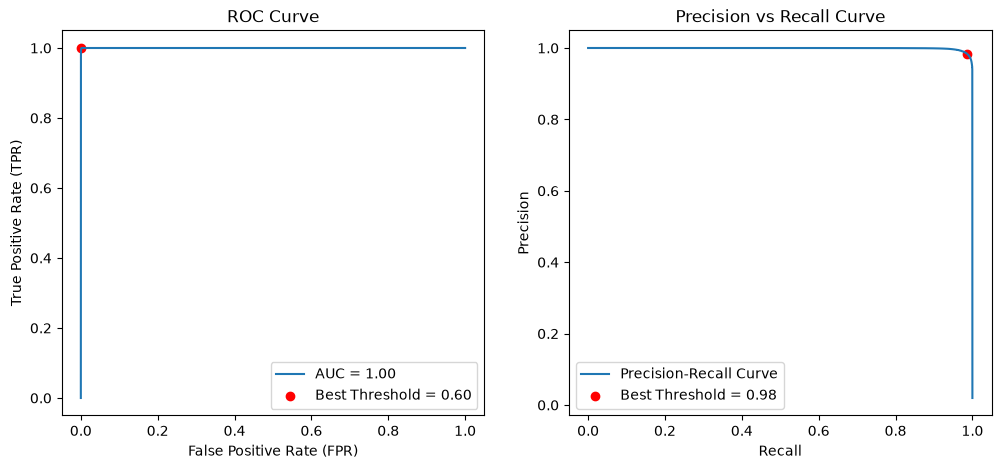

Train ROC threshold: 0.60
Train precision-recall threshold: 0.98


,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score,AUC-ROC,Jaccard Index,Cohen's Kappa,MCC,Threshold
Train,0.999406,0.982854,0.987033,0.999655,0.984935,0.999983,0.970325,0.984632,0.984637,0.977595
Test,0.999120,0.980236,0.975100,0.999603,0.977284,0.999942,0.956198,0.976837,0.977035,0.977595


In [12]:
threshold, results_df = evaluate_train_test(
    model,
    trainset,
    testset,
    metric_average="per_image",
)
save_evaluation_tables(
    OUTPUT_DIR,
    "cfp",
    results_df,
    metadata={
        "DATASET": "Screws",
        "MODEL": "U-Net MobileNetV2",
        "VARIANT": "CFP",
        "RUN_ID": RUN_ID,
        "SEED": SEED,
    },
)
results_df
